In [1]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from configs import Configs
configs = Configs()

from matplotlib import rcParams
rcParams.update({
    "font.size": 16,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans", "Liberation Sans"],
    "xtick.direction": "in",
    "ytick.direction": "in",
})



Text(0, 0.5, 'Loss')

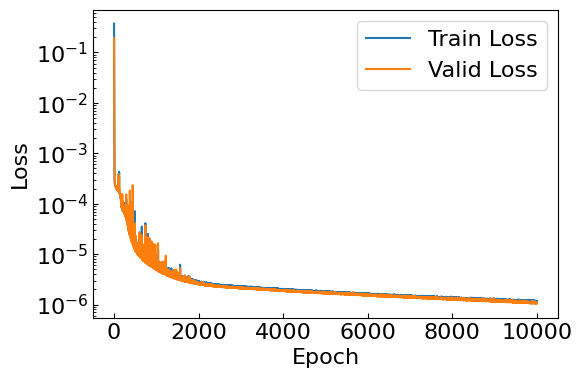

In [2]:
# read csv loss
import pandas as pd
save_dir = configs.save_dir
loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label="Train Loss")
ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label="Valid Loss")
if configs.physical_residual:
    ax.plot(loss_df["Epoch"], loss_df["ACLoss"], label="AC Loss")
    ax.plot(loss_df["Epoch"], loss_df["CHLoss"], label="CH Loss")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

Text(0, 0.5, 'MSE')

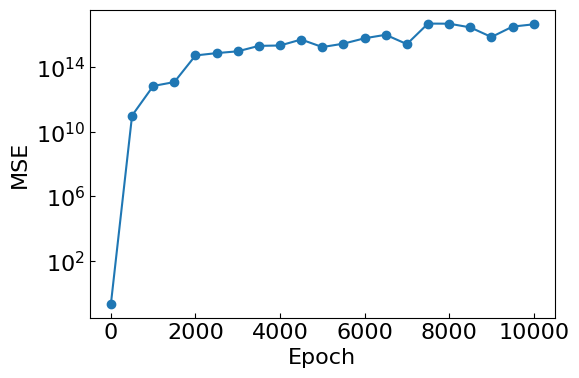

In [3]:
test_mse_df = pd.read_csv(os.path.join(save_dir, "test_logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(test_mse_df["Epoch"], test_mse_df["TestMSE"], label="Test MSE", marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")

In [5]:
# from model import FNO1d
from model1d import get_model1d

model_kwargs = {
   'modes': configs.modes,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}

# Add VAE-specific parameters if needed
if configs.model_type == 'vae':
   model_kwargs.update({
      'latent_dim': configs.latent_dim,
      'output_size': configs.output_size,
   })

model_skeleton = get_model1d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# model_skeleton = get_model1d(configs, jax.random.PRNGKey(0))
weight = os.path.join(save_dir, f"epoch_{configs.epochs - 1}.eqx")
fno = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [6]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_1d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_1d_complete.npz"))["times"]
dt = times[1] - times[0]
Xs.shape, Ys.shape

((175, 5, 101), (175, 2, 101))

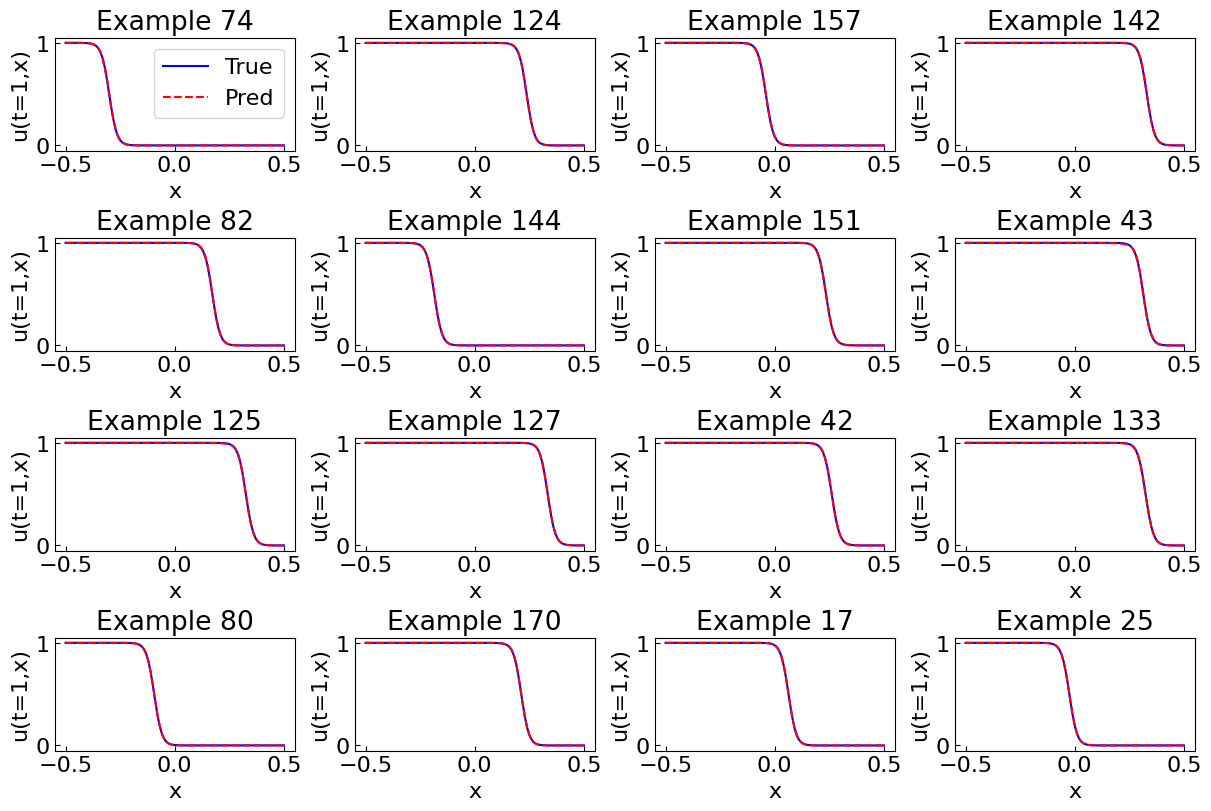

In [7]:
num_examples = 16
import numpy as np
random_indices = np.random.choice(Xs.shape[0], size=num_examples, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(12, 8), constrained_layout=True)
xs_example = Xs[random_indices]
ys_example = Ys[random_indices]
y_pred = jax.vmap(fno)(xs_example)
axes = axes.flatten()
for i, idx in enumerate(random_indices):
    ax = axes[i]
    # ax.plot(meshes, xs_example[i, 0, :], label="Input", color="green")
    ax.plot(meshes, ys_example[i, 0, :], label="True", color="blue")
    ax.plot(meshes, y_pred[i, 0, :], label="Pred", color="red", linestyle="dashed")
    ax.set_title(f"Example {idx}")
    if i == 0:
        ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("u(t=1,x)")

In [8]:
data_full = jnp.load(os.path.join(configs.data_dir, "dataset_1d_complete.npz"))
Xs_full = data_full["Xs"]
Ys_full = data_full["Ys"]
x_example = Xs_full[0:1]

lp = x_example[:, 2, 0]
times = data_full["times"]
meshes = data_full["meshes"]
dt = times[1] - times[0]
steps = 100
# y_auto_pred = fno.auto_reg(x_example[0, 0:2, :], lp, meshes, dt, steps=steps)
auto_reg_fn = jax.jit(jax.vmap(partial(fno.auto_reg, Lp=lp, meshes=meshes, dt=dt, steps=steps)))
y_auto_pred = auto_reg_fn(x_example[:, 0:2, :])[0]
y_example = Ys_full[0:steps]

In [9]:
times

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100.])

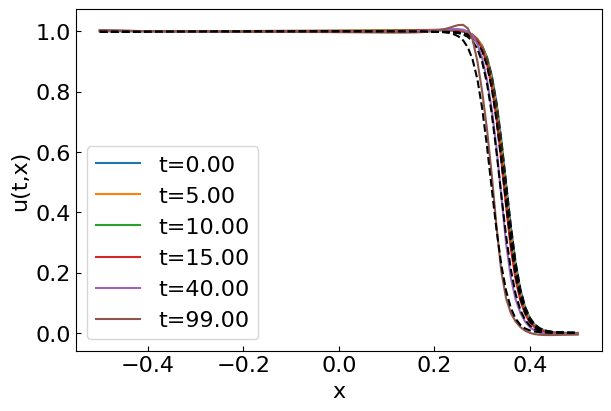

In [10]:
time_steps = [0, 5, 10, 15, 40, 99]
fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
for i, t in enumerate(time_steps):
    ax.plot(meshes, y_auto_pred[t, 0, :], label=f"t={times[t]:.2f}", color=f"C{i}", linestyle="-")
    ax.plot(meshes, y_example[t, 0, :], linestyle="dashed", color="black")

ax.set_xlabel("x")
ax.set_ylabel("u(t,x)")
ax.legend()

Max absolute error: 0.07160443


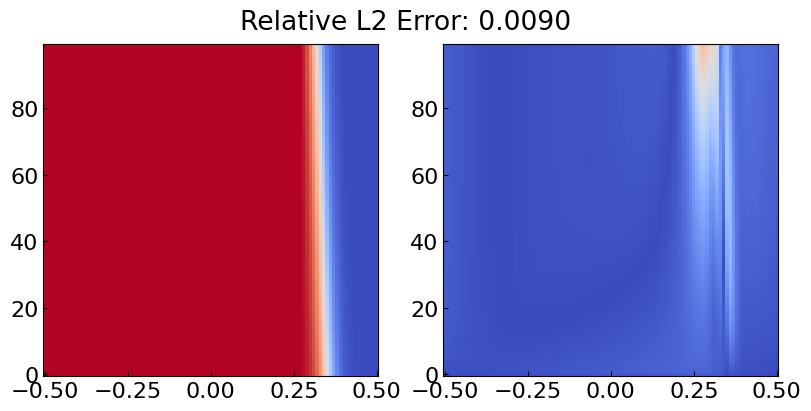

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
xmin, xmax = meshes.min(), meshes.max()
tmin, tmax = times[0], times[steps-1]
ax = axes[0]
ax.pcolormesh(meshes, times[0:steps], y_auto_pred[:, 0, :], shading="auto",
              cmap="coolwarm", vmin=0, vmax=1)
ax = axes[1]
ax.pcolormesh(meshes, times[0:steps], 
              jnp.abs(y_auto_pred[:, 0, :] - y_example[:, 0, :]), 
              shading="auto",
              cmap="coolwarm", vmin=0, vmax=0.1)
rel_l2 = jnp.linalg.norm(y_auto_pred - y_example) / jnp.linalg.norm(y_example)
fig.suptitle(f"Relative L2 Error: {rel_l2:.4f}")
print("Max absolute error:", jnp.max(jnp.abs(y_auto_pred - y_example)))

In [12]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions.npy"))[:, :, :, ::-1]
test_lp_values = jnp.load(os.path.join(configs.test_data_dir, "Lp_values.npy")).reshape(-1, 1)
test_meshes = jnp.load(os.path.join(configs.test_data_dir, "mesh_points.npy")).reshape(-1)[::-1]
test_times = jnp.load(os.path.join(configs.test_data_dir, "times.npy"))
# test_lp_values = -jnp.log10(test_lp_values) -5
test_lp_values = configs.Lpc(test_lp_values)
test_times = test_times / configs.Tc
test_meshes = test_meshes / configs.Lc
dt = test_times[1] - test_times[0]

In [13]:
x_test = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
auto_reg_fn = partial(
    fno.auto_reg,
    meshes=test_meshes,
    dt=jnp.array(dt),
    steps=test_times.shape[0]-1,
)
y_test_pred = jax.vmap(auto_reg_fn,
                       in_axes=(0, 0)
                       )(x_test, test_lp_values)

Total MSE on test set: 4.7004526e+16


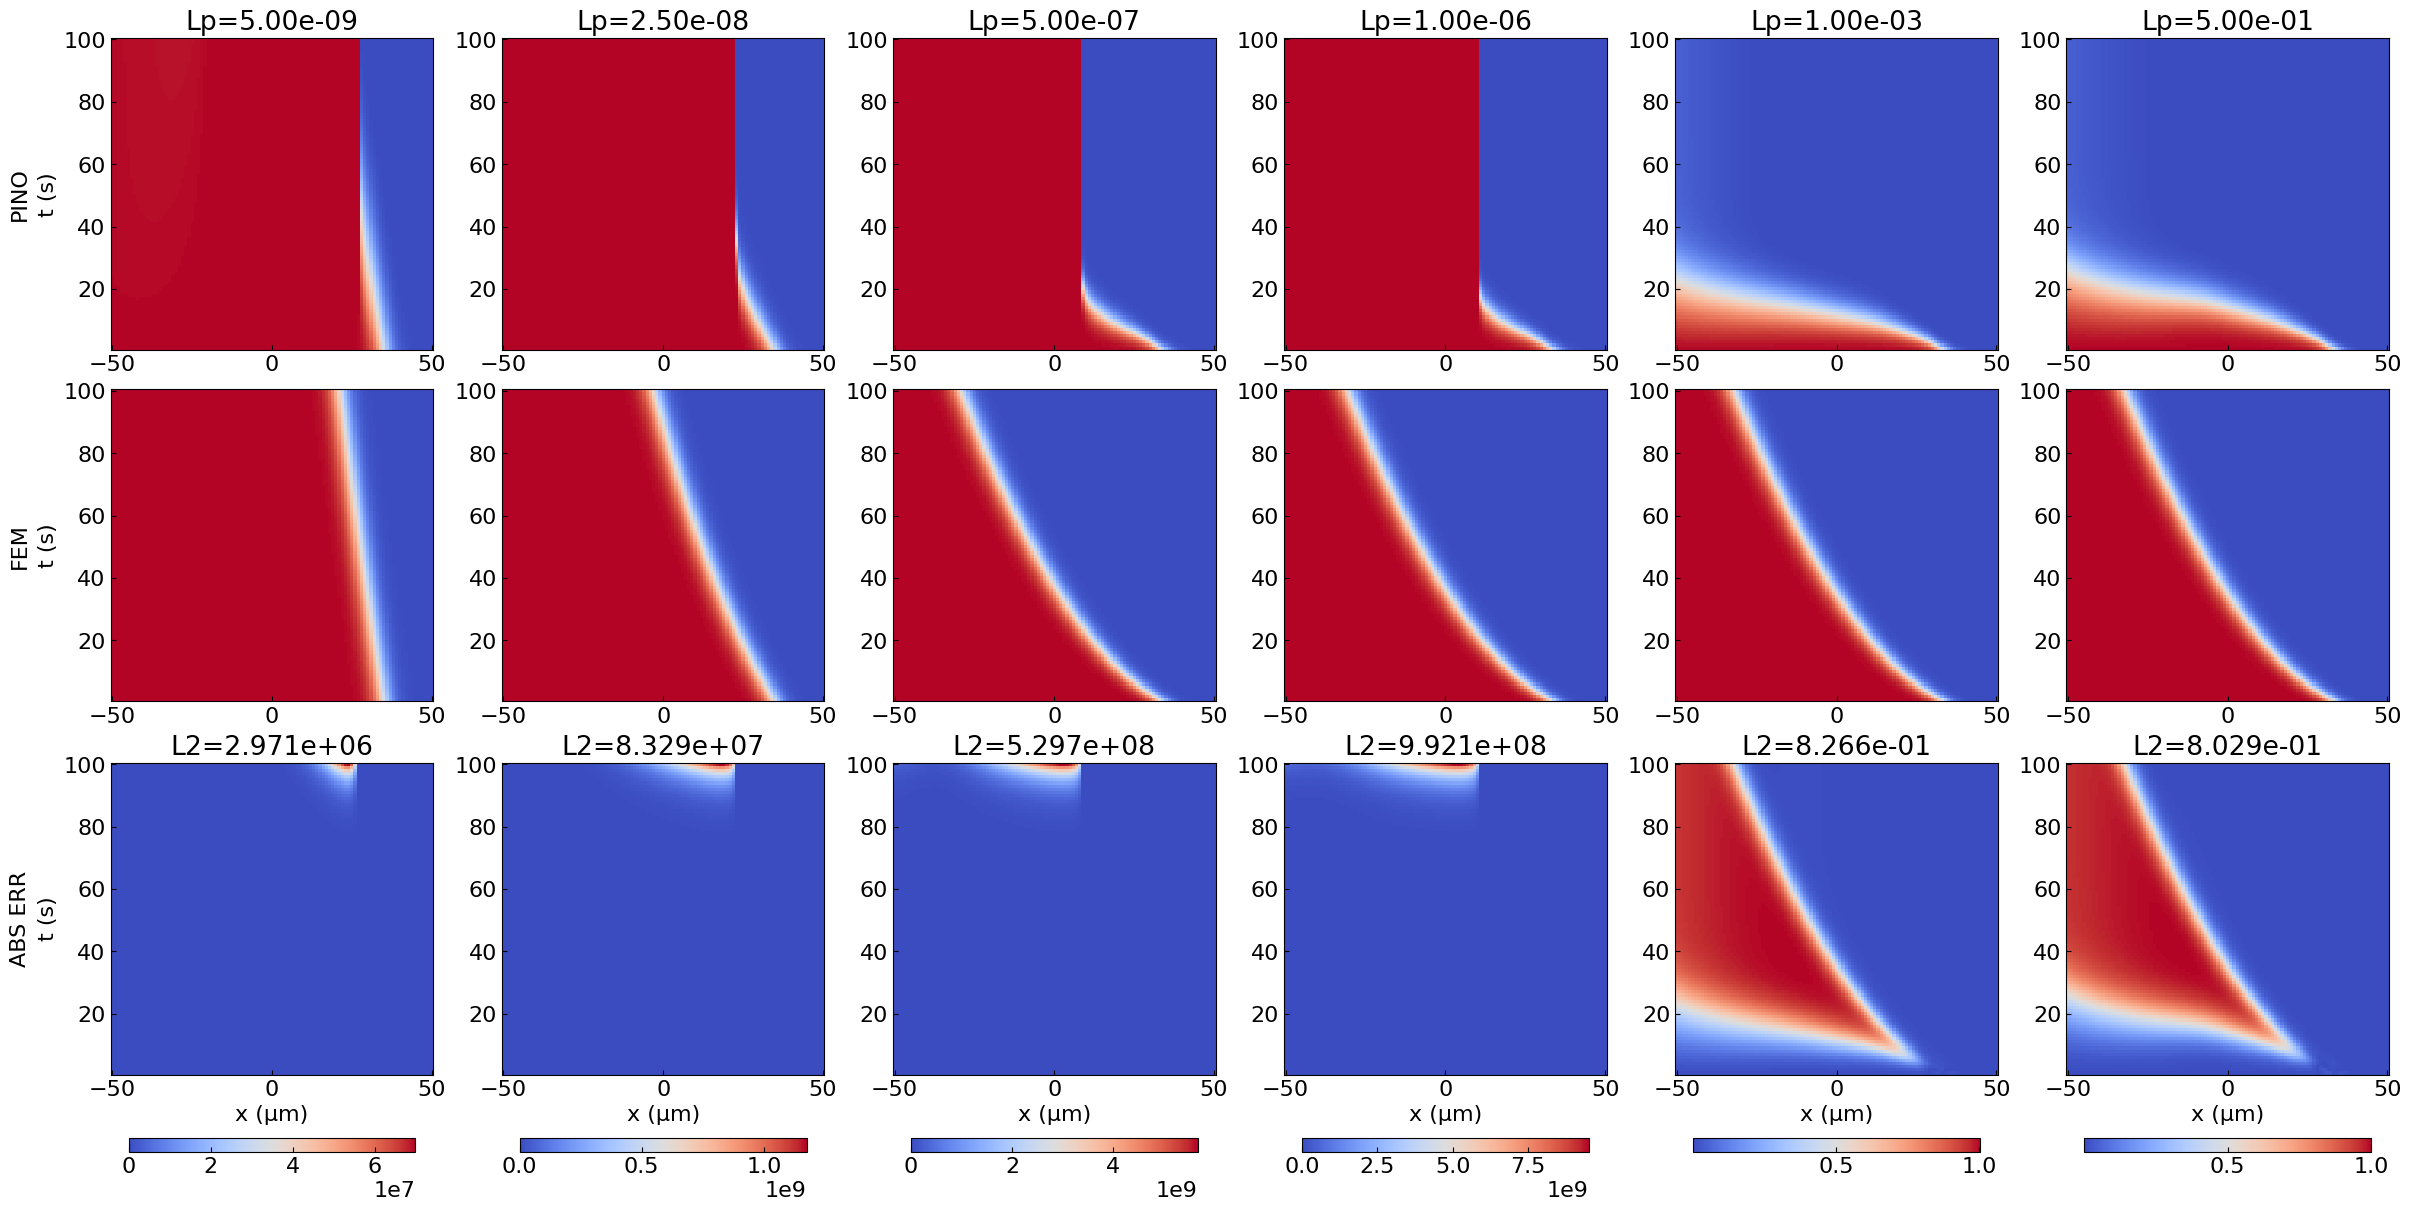

In [15]:
fig, axes = plt.subplots(3, 6, figsize=(4*6, 4*3), constrained_layout=True)
for i in range(6):
    ax = axes[0, i]
    sol = y_test_pred[i, :, 0, :]
    truth = y_test[i, :, 0, :]
    meshes_denorm = test_meshes * configs.Lc * 1e6
    times_denorm = test_times[1:] * configs.Tc
    ax.pcolormesh(meshes_denorm, times_denorm, sol, shading="auto",
                  cmap="coolwarm", vmin=0, vmax=1)
    lp_denorm = configs.Lp_from_Lpc(test_lp_values[i,0])
    ax.set_title(f"Lp={lp_denorm:.2e}")
    if i == 0:
        ax.set_ylabel("t (s)")
        ax.text(-0.25, 0.5, "PINO", va='center', ha="right",
                rotation='vertical', 
                transform=ax.transAxes, fontsize=16)
        
    ax = axes[1, i]
    sol = y_test_pred[i, :, 0, :]
    truth = y_test[i, :, 0, :]
    ax.pcolormesh(meshes_denorm, times_denorm,
                  truth, shading="auto",
                  cmap="coolwarm", vmin=0, vmax=1)
    if i == 0:
        ax.set_ylabel("t (s)")
        ax.text(-0.25, 0.5, "FEM", va='center', ha="right",
                rotation='vertical', 
                transform=ax.transAxes, fontsize=16)
        
    ax = axes[2, i]
    err_bar = ax.pcolormesh(meshes_denorm, times_denorm,
                  jnp.abs(sol - truth), shading="auto",
                  cmap="coolwarm",)
    L2_err = jnp.linalg.norm(sol - truth) / jnp.linalg.norm(truth)
    ax.set_title(f"L2={L2_err:.3e}")
    ax.set_xlabel("x (µm)")
    if i == 0:
        ax.set_ylabel("t (s)")
        ax.text(-0.25, 0.5, "ABS ERR", va='center', ha="right",
                rotation='vertical', 
                transform=ax.transAxes, fontsize=16)
    # add a colorbar to the last row
    fig.colorbar(err_bar, ax=axes[2, i], orientation='horizontal', fraction=0.046, pad=0.04)

# total mse
total_mse = jnp.mean((y_test_pred - y_test)**2)
print("Total MSE on test set:", total_mse)
    

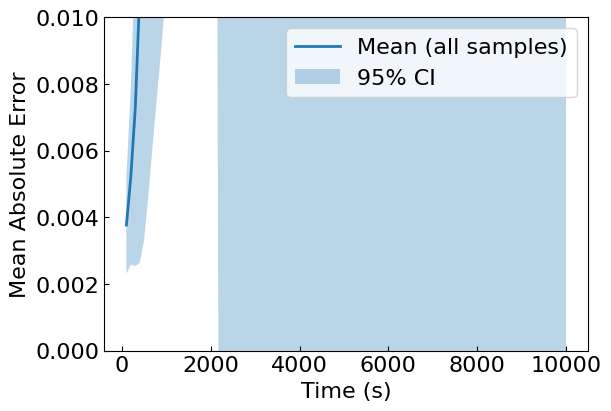

In [16]:
import numpy as np
# absolute error per sample, per time, per channel, per x-point
error = jnp.abs(y_test_pred - y_test)
# mean over channels and spatial points -> shape (N_samples, N_times)
mean_error = jnp.mean(error, axis=(2,3))
# x axis (time) in seconds
x = np.array(test_times[1:]*100)
# compute overall mean and 95% CI across all samples
group = np.array(mean_error)  # shape (N_samples, N_times)
mean = group.mean(axis=0)
# use sample std (ddof=1) when more than one sample, else zeros
std = group.std(axis=0, ddof=1) if group.shape[0] > 1 else np.zeros_like(mean)
n = group.shape[0]
sem = std / np.sqrt(n) if n > 1 else np.zeros_like(std)
ci_95 = 1.96 * sem  # approx 95% CI (normal approx)
ci_90 = 1.64 * sem  # approx 90% CI (normal approx)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
ax.plot(x, mean, label="Mean (all samples)", lw=2)
ax.fill_between(x, mean - ci_95, mean + ci_95, alpha=0.3, label="95% CI")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean Absolute Error")
ax.set_ylim(0, 1e-2)
ax.legend()
plt.show()

In [15]:
np.savez(
    os.path.join(configs.save_dir, "test_results.npz"),
    y_test=y_test,
    y_test_pred=y_test_pred,
)